# Data modeling
Uses the shared logic in `src/` so the notebook and the app follow the same rules (see `assumptions.md`).

In [1]:
import pandas as pd

from src.loader import load_shifts, load_holidays, load_payroll
from src.hours import parse_shifts, attribute_hours, data_cutoff, quality_report
from src.integrity import find_duplicate_people, add_person_key, find_overlaps

shifts_raw = load_shifts("data/shifts.csv")
holidays = load_holidays("data/public_holidays.csv")
employees = pd.read_csv("data/employees.csv")
sites = pd.read_csv("data/sites.csv")
notes = pd.read_csv("data/shift_notes.csv")
weekly_summary = pd.read_csv("data/weekly_summary.csv")

shifts_raw.head()

,shift_id,employee_id,site_id,shift_date,clock_in_time,clock_out_time
0,S100048,E1002,ST-02,2026-06-08,07:00,15:15
1,S100191,E1005,ST-05,2026-06-08,08:00,16:15
2,S100355,E1009,ST-02,2026-06-08,08:00,20:15
3,S100449,E1011,ST-01,2026-06-08,09:30,19:30
4,S100574,E1014,ST-03,2026-06-08,06:00,17:30


## Parse shifts and data quality
Overnight = clock-out earlier than clock-in (+24h). Empty/invalid times are flagged and excluded. Shifts over 12 hours are flagged but counted.

In [2]:
shifts = parse_shifts(shifts_raw)
quality_report(shifts)

{'shifts': 8863,
 'overnight': 1010,
 'over_12h_flagged': 1279,
 'invalid_date': 0,
 'invalid_clock_in': 0,
 'invalid_clock_out': 184,
 'zero_duration': 0,
 'excluded': 184}

In [3]:
assert (shifts.loc[~shifts.excluded, "duration_hours"] > 0).all()
print("shortest / longest counted shift:", shifts.duration_hours.min(), shifts.duration_hours.max())
print("flagged invalid (excluded):", shifts.excluded.sum())
shifts[shifts.excluded][["shift_id", "employee_id", "shift_date", "clock_in_time", "clock_out_time"]].head()

shortest / longest counted shift: 3.5 13.5
flagged invalid (excluded): 184


,shift_id,employee_id,shift_date,clock_in_time,clock_out_time
138,S100245,E1006,2026-06-09,07:15,NaN
154,S101273,E1030,2026-06-09,07:00,NaN
176,S102834,E1065,2026-06-09,19:30,NaN
237,S107084,E1162,2026-06-09,09:00,NaN
250,S107993,E1182,2026-06-09,18:00,NaN


## Attribute hours to a day and week (greater-portion rule)
A shift crossing midnight goes whole to the day with the greater portion; an exact tie is split at midnight. The attributed day sets the week and the 2x Sunday / public-holiday rate.

In [4]:
segments = attribute_hours(shifts, holidays)

cutoff = data_cutoff(shifts)
current_week = cutoff - pd.Timedelta(days=cutoff.weekday())
print("data ends", cutoff.date(), cutoff.day_name(), "-> in-progress week starts", current_week.date())
print("segments:", len(segments), "| split ties:", len(segments) - (~shifts.excluded).sum())
print("2x segments (Sunday or public holiday):", (segments.multiplier == 2.0).sum())

data ends 2026-08-12 Wednesday -> in-progress week starts 2026-08-10
segments: 8726 | split ties: 47
2x segments (Sunday or public holiday): 1463


## Integrity flags (potential fraud, for escalation)
**Duplicate people:** employee IDs sharing an ID number, bank account or tax number. Bank and tax values are compared in memory only and are never shown. **Overlapping shifts:** one person at two sites at the same time. Overlapping hours are still counted; they are only flagged.

In [5]:
payroll = load_payroll("data/payroll_details.csv")   # employee_id, account_number, tax_number only
people = find_duplicate_people(employees, payroll)
del payroll                                          # not kept around

print("duplicate people:", len(people), "| escalate:", (people.severity == "Escalate").sum())
people[["person_key", "employee_ids", "names", "evidence", "severity"]]

duplicate people: 5 | escalate: 5


,person_key,employee_ids,names,evidence,severity
0,E1035,"[E1035, E1036]","[Tshepo Motaung, T. Motaung]",same ID number; same bank account; same tax nu...,Escalate
1,E1090,"[E1090, E1091]","[Pieter Van Wyk, P. Van Wyk]",same ID number; same bank account; same tax nu...,Escalate
2,E1097,"[E1097, E1098]","[Busisiwe Jacobs, B. Jacobs]",same ID number; same bank account; same tax nu...,Escalate
3,E1126,"[E1126, E1127]","[Lerato Motaung, L. Motaung]",same ID number; same bank account; same tax nu...,Escalate
4,E1193,"[E1193, E1194]","[Lucky Sibiya, L. Sibiya]",same ID number; same bank account; same tax nu...,Escalate


In [6]:
overlaps = find_overlaps(shifts, sites, people)

print("overlapping shift pairs:", len(overlaps))
print(overlaps.groupby("kind").agg(pairs=("shift_id_a", "count"),
                                   people=("person_key", "nunique"),
                                   different_province=("different_province", "sum"),
                                   overlap_hours=("overlap_hours", "sum")))
print("high severity (different provinces):", (overlaps.severity == "High").sum())
overlaps[["person_key", "kind", "site_a", "site_b", "start_a", "end_a", "start_b", "end_b", "overlap_hours", "severity"]].head(8)

overlapping shift pairs: 195


          pairs  people  different_province  overlap_hours
kind                                                      
cross_id     69       5                  31         510.00
same_id     126      81                  99         432.75
high severity (different provinces): 130


,person_key,kind,site_a,site_b,start_a,end_a,start_b,end_b,overlap_hours,severity
0,E1005,same_id,ST-05,ST-04,2026-07-01 06:00:00,2026-07-01 14:15:00,2026-07-01 08:00:00,2026-07-01 12:00:00,4.00,High
1,E1006,same_id,ST-02,ST-04,2026-06-16 06:00:00,2026-06-16 10:00:00,2026-06-16 06:00:00,2026-06-16 18:00:00,4.00,High
2,E1006,same_id,ST-04,ST-01,2026-06-22 06:00:00,2026-06-22 17:15:00,2026-06-22 08:30:00,2026-06-22 12:30:00,4.00,High
3,E1007,same_id,ST-06,ST-02,2026-07-04 06:30:00,2026-07-04 19:00:00,2026-07-04 09:00:00,2026-07-04 13:00:00,4.00,High
4,E1015,same_id,ST-05,ST-06,2026-07-14 08:00:00,2026-07-14 17:45:00,2026-07-14 09:15:00,2026-07-14 13:15:00,4.00,High
5,E1015,same_id,ST-06,ST-05,2026-07-17 06:00:00,2026-07-17 10:00:00,2026-07-17 06:15:00,2026-07-17 15:15:00,3.75,High
6,E1016,same_id,ST-05,ST-04,2026-06-26 06:00:00,2026-06-26 10:00:00,2026-06-26 06:00:00,2026-06-26 16:15:00,4.00,High
7,E1019,same_id,ST-05,ST-02,2026-08-05 06:15:00,2026-08-05 15:45:00,2026-08-05 08:15:00,2026-08-05 12:15:00,4.00,High


## Person-level weekly hours
Hours are summed across all employee IDs of one person (recorded hours, overlaps counted), because splitting hours across two IDs is what hides a breach.

In [7]:
segments = add_person_key(segments, people)
complete_weeks = segments["week_start"] < current_week

per_id = segments.groupby(["employee_id", "week_start"])["hours"].sum()
per_person = segments.groupby(["person_key", "week_start"])["hours"].sum()

breach_id = ((per_id - 45) > 10)[per_id.index.get_level_values(1) < current_week]
breach_person = ((per_person - 45) > 10)[per_person.index.get_level_values(1) < current_week]
print("breach-weeks, per employee ID :", breach_id.sum())
print("breach-weeks, per person      :", breach_person.sum())

dup_keys = list(people.person_key)
per_person.loc[dup_keys].unstack(0).round(1)

breach-weeks, per employee ID : 87
breach-weeks, per person      : 114


person_key,E1035,E1090,E1097,E1126,E1193
week_start,,,,,
2026-06-08,62.8,66.8,65.5,51.5,53.0
2026-06-15,54.5,56.5,53.5,56.0,46.8
2026-06-22,61.2,54.2,66.2,60.2,55.2
2026-06-29,41.2,58.8,55.5,61.8,54.8
2026-07-06,40.2,57.8,66.0,56.8,50.0
2026-07-13,52.5,53.5,51.8,71.8,57.0
2026-07-20,59.5,63.5,67.0,46.5,57.0
2026-07-27,51.8,53.2,55.2,56.0,59.8
2026-08-03,60.2,53.2,52.5,65.2,66.5


## Compare with the client's `weekly_summary.csv`
The client's totals follow a different rule (clock-in date, missing clock-outs as 0, no person merge), so some employee-weeks should differ.

In [8]:
weekly = segments.groupby(["employee_id", "week_start"])["hours"].sum().reset_index()

cmp = weekly_summary.assign(week_starting=pd.to_datetime(weekly_summary.week_starting)).merge(
    weekly, left_on=["employee_id", "week_starting"], right_on=["employee_id", "week_start"], how="outer")
cmp["diff"] = cmp["hours"].fillna(0) - cmp["total_hours"].fillna(0)
print("employee-weeks:", len(cmp), "| differ from client summary:", (cmp["diff"].abs() > 0.01).sum())
cmp[cmp["diff"].abs() > 0.01].sort_values("diff", key=abs, ascending=False).head(10)[["employee_id", "week_starting", "total_hours", "hours", "diff"]]

employee-weeks: 2124 | differ from client summary: 122


,employee_id,week_starting,total_hours,hours,diff
34,E1004,2026-07-06,46.25,32.75,-13.5
850,E1086,2026-06-15,49.25,35.75,-13.5
1797,E1181,2026-06-22,37.50,51.00,13.5
1796,E1181,2026-06-15,47.75,34.25,-13.5
778,E1078,2026-08-10,13.00,26.50,13.5
1581,E1159,2026-07-13,43.50,57.00,13.5
1580,E1159,2026-07-06,37.25,23.75,-13.5
802,E1081,2026-06-29,35.50,22.00,-13.5
1456,E1146,2026-08-10,25.25,38.75,13.5
819,E1083,2026-06-08,38.00,24.50,-13.5


## People averaging more than 45 hours a week
Per person (all their IDs combined), complete Mon-Sun weeks only.

In [9]:
person_weekly = per_person.reset_index()
complete = person_weekly[person_weekly["week_start"] < current_week]
avg_hours = complete.groupby("person_key")["hours"].mean().rename("avg_weekly_hours")
over_45 = avg_hours[avg_hours > 45].sort_values(ascending=False).reset_index()
over_45["merged_duplicate"] = over_45["person_key"].isin(dup_keys)
print("people averaging over 45 hours/week:", len(over_45), "| of which merged duplicates:", over_45.merged_duplicate.sum())
over_45.merge(employees[["employee_id", "full_name", "role", "primary_site_id"]], left_on="person_key", right_on="employee_id").drop(columns="employee_id").head(20)

people averaging over 45 hours/week: 59 | of which merged duplicates: 5


,person_key,avg_weekly_hours,merged_duplicate,full_name,role,primary_site_id
0,E1097,59.250000,True,Busisiwe Jacobs,Supervisor,ST-02
1,E1126,58.416667,True,Lerato Motaung,Supervisor,ST-06
2,E1090,57.500000,True,Pieter Van Wyk,Cleaner,ST-05
3,E1193,55.555556,True,Lucky Sibiya,Kitchen Assistant,ST-03
4,E1035,53.777778,True,Tshepo Motaung,Security Guard,ST-01
5,E1039,52.694444,False,Pieter Naidoo,Kitchen Assistant,ST-04
6,E1122,52.111111,False,Dineo Tshabalala,Kitchen Assistant,ST-03
7,E1061,51.583333,False,Pieter Baloyi,Supervisor,ST-01
8,E1198,51.166667,False,Andile Jacobs,Supervisor,ST-04
9,E1184,50.333333,False,Portia Motaung,Security Guard,ST-06


# Prediction model
Goal: predict who exceeds 10 hours of overtime (more than 55 total hours) in the Mon-Sun week still in progress when the data stops. Logistic regression, compared against simple baselines on rolling time-based folds.

Rules used (see `assumptions.md`): greater-portion week attribution, duplicate IDs merged into one person, missing clock-outs excluded (imputation only as a sensitivity run), Sunday and holiday hours count as normal hours toward the cap. The cutoff is the last `shift_date` in the data, expressed as an offset from Monday so every training week is cut at the same point.

In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

OFFSET = (cutoff - current_week).days      # days after Monday that the data stops (2 = Wednesday)
CAP = 55                                   # breach = attributed hours strictly over this
print("cutoff", cutoff.date(), "| offset from Monday:", OFFSET, "days | in-progress week", current_week.date())

seg_base = segments.merge(shifts[["shift_id", "shift_date"]], on="shift_id")[
    ["shift_id", "person_key", "shift_date", "week_start", "hours"]]

person_ids = add_person_key(employees[["employee_id", "full_name", "shift_pattern"]], people)
persons = sorted(person_ids["person_key"].unique())
night = person_ids.assign(n=person_ids.shift_pattern.eq("night")).groupby("person_key")["n"].max().astype(int)
weeks = pd.date_range(seg_base.week_start.min(), current_week, freq="7D")
dup_keys = set(people.person_key)
global_shift_len = seg_base["hours"].mean()
print(len(persons), "persons x", len(weeks), "weeks (last = in progress)")

cutoff 2026-08-12 | offset from Monday: 2 days | in-progress week 2026-08-10
208 persons x 10 weeks (last = in progress)


## 1. Person-week table and features at the cutoff
One row per person per week. "So far" = shifts clocked in on or before Monday + offset, which includes Sunday-start shifts attributed to Monday and Wednesday-night shifts attributed to Thursday. History features use completed prior weeks only.

In [11]:
FEATS = ["hours_so_far", "shifts_so_far", "avg_weekly_hours_prior", "avg_shifts_prior",
         "share_long_shifts_prior", "prior_breaches", "night_pattern"]

def build_table(seg):
    seg = seg.copy()
    seg["so_far"] = seg["shift_date"] <= seg["week_start"] + pd.Timedelta(days=OFFSET)
    seg["long"] = seg["hours"] > 11
    t = pd.DataFrame(index=pd.MultiIndex.from_product([persons, weeks], names=["person_key", "week_start"]))
    g = seg.groupby(["person_key", "week_start"])
    gs = seg[seg["so_far"]].groupby(["person_key", "week_start"])
    t["final_hours"] = g["hours"].sum()
    t["shifts"] = g["shift_id"].nunique()
    t["long_shifts"] = g["long"].sum()
    t["hours_so_far"] = gs["hours"].sum()
    t["shifts_so_far"] = gs["shift_id"].nunique()
    t = t.fillna(0)
    t["breach"] = (t["final_hours"] > CAP).astype(float)
    # history = completed prior weeks only (cumulative sum minus the current week)
    byp = t.groupby(level=0)
    for col in ["final_hours", "shifts", "long_shifts", "breach"]:
        t["prior_" + col] = byp[col].cumsum() - t[col]
    n_prior = byp.cumcount()
    t["n_prior_weeks"] = n_prior
    t["avg_weekly_hours_prior"] = t["prior_final_hours"] / n_prior.replace(0, np.nan)
    t["avg_shifts_prior"] = t["prior_shifts"] / n_prior.replace(0, np.nan)
    t["share_long_shifts_prior"] = (t["prior_long_shifts"] / t["prior_shifts"].replace(0, np.nan)).fillna(0)
    t["prior_breaches"] = t["prior_breach"]
    t["typical_shift_len"] = (t["prior_final_hours"] / t["prior_shifts"].replace(0, np.nan)).fillna(global_shift_len)
    t["night_pattern"] = night.reindex(t.index.get_level_values(0)).values
    # baselines (projected final hours)
    t["B1"] = t["hours_so_far"]
    t["B2"] = t["hours_so_far"] * 7 / (OFFSET + 1)
    t["B3"] = t["hours_so_far"] + (t["avg_shifts_prior"] - t["shifts_so_far"]).clip(lower=0) * t["typical_shift_len"]
    t["B4"] = t["avg_weekly_hours_prior"]
    t = t.reset_index()
    t.loc[t["week_start"] == current_week, "breach"] = np.nan      # the week we predict has no label
    return t[t["n_prior_weeks"] > 0].reset_index(drop=True)         # week 1 gives history only

table = build_table(seg_base)
labelled = table[table.week_start < current_week]
print("labelled person-weeks:", len(labelled), "| positives:", int(labelled.breach.sum()), "| rate:", round(labelled.breach.mean(), 3))
print("positives per week:", labelled.groupby("week_start").breach.sum().astype(int).tolist())
print("positives without the 5 merged people:", int(labelled[~labelled.person_key.isin(dup_keys)].breach.sum()))
labelled[FEATS].describe().T.round(2)

labelled person-weeks: 1664 | positives: 104 | rate: 0.062
positives per week: [7, 15, 14, 16, 16, 17, 11, 8]
positives without the 5 merged people: 80


,count,mean,std,min,25%,50%,75%,max
hours_so_far,1664.0,19.25,8.03,0.0,12.50,18.75,25.00,48.50
shifts_so_far,1664.0,1.96,0.84,0.0,1.00,2.00,2.00,5.00
avg_weekly_hours_prior,1664.0,43.08,5.02,23.0,40.00,43.00,45.93,66.75
avg_shifts_prior,1664.0,4.40,0.80,2.0,4.00,4.40,5.00,8.00
share_long_shifts_prior,1664.0,0.31,0.34,0.0,0.05,0.11,0.69,1.00
prior_breaches,1664.0,0.27,0.69,0.0,0.00,0.00,0.00,6.00
night_pattern,1664.0,0.14,0.35,0.0,0.00,0.00,0.00,1.00


## 2. Leakage checks
Independent recomputation of features for random person-weeks, and checks that nothing after the cutoff offset or from the same week leaks into history.

In [12]:
rng = np.random.default_rng(0)
sample = labelled.sample(40, random_state=0)
for r in sample.itertuples():
    mine = seg_base[(seg_base.person_key == r.person_key) & (seg_base.week_start == r.week_start)]
    so_far = mine[mine.shift_date <= r.week_start + pd.Timedelta(days=OFFSET)]
    assert abs(so_far.hours.sum() - r.hours_so_far) < 1e-9, "hours_so_far mismatch"
    assert so_far.shift_id.nunique() == r.shifts_so_far
    assert (so_far.shift_date <= r.week_start + pd.Timedelta(days=OFFSET)).all()      # nothing after the cutoff
    prior = seg_base[(seg_base.person_key == r.person_key) & (seg_base.week_start < r.week_start)]
    n_prior_weeks = int(r.n_prior_weeks)
    assert abs(prior.hours.sum() / n_prior_weeks - r.avg_weekly_hours_prior) < 1e-9, "history mismatch"
assert (table.loc[table.week_start == current_week, "breach"].isna()).all()
assert (labelled.hours_so_far <= labelled.final_hours + 1e-9).all()
print("leakage checks passed on", len(sample), "random person-weeks")

leakage checks passed on 40 random person-weeks


## 3. Rolling folds, baselines and model
Expanding window, never random: train on weeks 2..k, test on week k+1, for test weeks 5 to 9. Regularisation is chosen with an inner time-split inside the training weeks only.

In [13]:
C_GRID = [0.01, 0.03, 0.1, 0.3, 1, 3, 10]

def make_model(C):
    return make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))

def choose_C(tbl, k, feats):
    # inner time-split inside training weeks weeks[1:k] only
    scores = {C: [] for C in C_GRID}
    for j in range(max(2, k - 3), k):
        tr = tbl[tbl.week_start.isin(weeks[1:j])]
        te = tbl[tbl.week_start == weeks[j]]
        if tr.breach.sum() < 3 or te.breach.sum() < 1:
            continue
        for C in C_GRID:
            m = make_model(C).fit(tr[feats], tr.breach)
            scores[C].append(average_precision_score(te.breach, m.predict_proba(te[feats])[:, 1]))
    valid = {C: np.mean(v) for C, v in scores.items() if v}
    return max(valid, key=valid.get) if valid else 1

def rolling_cv(tbl, feats, test_idx=range(4, 9), keep_models=False):
    out, models = [], []
    for k in test_idx:
        tr = tbl[tbl.week_start.isin(weeks[1:k])]
        te = tbl[tbl.week_start == weeks[k]]
        C = choose_C(tbl, k, feats)
        m = make_model(C).fit(tr[feats], tr.breach)
        out.append(te[["person_key", "week_start", "breach"]].assign(score=m.predict_proba(te[feats])[:, 1], fold=k + 1, C=C))
        models.append((k, m, te))
    return (pd.concat(out), models) if keep_models else pd.concat(out)

def baseline_oof(tbl, col, test_idx=range(4, 9)):
    te = tbl[tbl.week_start.isin([weeks[k] for k in test_idx])]
    return te[["person_key", "week_start", "breach"]].assign(score=te[col].values, fold=te.week_start.map({weeks[k]: k + 1 for k in test_idx}).values)

def f2_at(y, flag):
    tp = ((flag == 1) & (y == 1)).sum(); fp = ((flag == 1) & (y == 0)).sum(); fn = ((flag == 0) & (y == 1)).sum()
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return (5 * p * r / (4 * p + r) if p + r else 0.0), p, r

def best_threshold(y, s):
    cands = np.unique(s)
    return cands[int(np.argmax([f2_at(y.values, (s.values >= c).astype(int))[0] for c in cands]))]

def summarize(oof, drop_merged=False):
    d = oof[~oof.person_key.isin(dup_keys)] if drop_merged else oof
    thr = best_threshold(d.breach, d.score)
    flag = (d.score >= thr).astype(int)
    f2, p, r = f2_at(d.breach.values, flag.values)
    per_fold = [average_precision_score(g.breach, g.score) for _, g in d.groupby("fold")]
    top25 = np.mean([g.nlargest(25, "score").breach.sum() / max(g.breach.sum(), 1) for _, g in d.groupby("fold")])
    return {"PR-AUC": average_precision_score(d.breach, d.score), "fold PR-AUCs": [round(x, 2) for x in per_fold],
            "threshold": round(float(thr), 3), "precision": round(p, 2), "recall": round(r, 2), "F2": round(f2, 2),
            "flagged/week": round(flag.groupby(d.fold).sum().mean(), 1), "recall@25": round(top25, 2)}

oof = {name: baseline_oof(table, name) for name in ["B1", "B2", "B3", "B4"]}
oof["LR"], fold_models = rolling_cv(table, FEATS, keep_models=True)

print("Fold sizes (train weeks 2..k -> test week k+1):")
for k, m, te in fold_models:
    tr = table[table.week_start.isin(weeks[1:k])]
    print(f"  train weeks 2-{k}: {len(tr)} rows, {int(tr.breach.sum())} positives | test week {k+1}: {len(te)} rows, {int(te.breach.sum())} positives | C={oof['LR'][oof['LR'].fold==k+1].C.iloc[0]}")

comparison = pd.DataFrame({k: summarize(v) for k, v in oof.items()}).T
comparison

Fold sizes (train weeks 2..k -> test week k+1):
  train weeks 2-4: 624 rows, 36 positives | test week 5: 208 rows, 16 positives | C=0.1
  train weeks 2-5: 832 rows, 52 positives | test week 6: 208 rows, 16 positives | C=0.1
  train weeks 2-6: 1040 rows, 68 positives | test week 7: 208 rows, 17 positives | C=0.1
  train weeks 2-7: 1248 rows, 85 positives | test week 8: 208 rows, 11 positives | C=0.3
  train weeks 2-8: 1456 rows, 96 positives | test week 9: 208 rows, 8 positives | C=10.0


,PR-AUC,fold PR-AUCs,threshold,precision,recall,F2,flagged/week,recall@25
B1,0.308997,"[0.44, 0.44, 0.26, 0.26, 0.17]",25.25,0.18,0.68,0.44,50.0,0.49
B2,0.308997,"[0.44, 0.44, 0.26, 0.26, 0.17]",58.917,0.18,0.68,0.44,50.0,0.49
B3,0.334248,"[0.33, 0.25, 0.47, 0.38, 0.38]",47.644,0.25,0.59,0.46,31.8,0.48
B4,0.296272,"[0.35, 0.22, 0.5, 0.36, 0.27]",47.35,0.26,0.57,0.46,29.6,0.5
LR,0.430001,"[0.59, 0.37, 0.46, 0.54, 0.55]",0.096,0.25,0.69,0.51,37.4,0.55


Same comparison without the 5 merged people. They breach in almost every week, so they make `prior_breaches` look more useful than it is for everyone else.

Note: precision, recall and F2 are measured at the F2-optimal threshold chosen on these same out-of-fold predictions, so they are slightly optimistic. PR-AUC does not depend on a threshold. B1 and B2 rank people identically (B2 is B1 times a constant), so they share a PR-AUC.

In [14]:
pd.DataFrame({k: summarize(v, drop_merged=True) for k, v in oof.items()}).T

,PR-AUC,fold PR-AUCs,threshold,precision,recall,F2,flagged/week,recall@25
B1,0.262682,"[0.41, 0.45, 0.14, 0.25, 0.09]",25.25,0.15,0.68,0.4,47.4,0.45
B2,0.262682,"[0.41, 0.45, 0.14, 0.25, 0.09]",58.917,0.15,0.68,0.4,47.4,0.45
B3,0.166777,"[0.19, 0.22, 0.29, 0.18, 0.09]",47.644,0.19,0.47,0.36,26.8,0.41
B4,0.151436,"[0.14, 0.18, 0.38, 0.13, 0.09]",47.35,0.2,0.45,0.36,24.6,0.45
LR,0.356593,"[0.48, 0.4, 0.37, 0.37, 0.34]",0.077,0.18,0.75,0.46,45.2,0.51


In [15]:
# Decision rule: ship the model only if it clearly beats baseline B3 (pooled PR-AUC and at least 3 of 5 folds)
lr_f = [average_precision_score(g.breach, g.score) for _, g in oof["LR"].groupby("fold")]
b3_f = [average_precision_score(g.breach, g.score) for _, g in oof["B3"].groupby("fold")]
folds_won = sum(a > b for a, b in zip(lr_f, b3_f))
pooled_lr = average_precision_score(oof["LR"].breach, oof["LR"].score)
pooled_b3 = average_precision_score(oof["B3"].breach, oof["B3"].score)
LR_WINS = (pooled_lr > pooled_b3) and (folds_won >= 3)
print(f"pooled PR-AUC: LR {pooled_lr:.3f} vs B3 {pooled_b3:.3f} | LR wins {folds_won} of 5 folds")
print("DECISION:", "ship logistic regression" if LR_WINS else "ship baseline B3 (calibrated to a probability)")

pooled PR-AUC: LR 0.430 vs B3 0.334 | LR wins 4 of 5 folds
DECISION: ship logistic regression


## Performance by training window
The windows are expanding, not fixed-length: each one starts at week 2 and ends one week later than the previous one, then tests on the following week. So window 1 trains on weeks 2-4 and tests on week 5, and window 5 trains on weeks 2-8 and tests on week 9.

Precision, recall and F2 use one pooled F2 threshold (the same one used for `predictions.csv`), chosen on all out-of-fold weeks, so they are slightly optimistic per window. PR-AUC does not use a threshold. The "random list" column is the PR-AUC you would get by ranking at random (the test week's breach rate).

In [16]:
import matplotlib.pyplot as plt

WINDOW_THRESHOLD = best_threshold(oof["LR"].breach, oof["LR"].score)   # pooled F2 threshold, same rule as the final model

def window_row(label, fold_no, train, test_rows):
    o = oof["LR"][oof["LR"].fold == fold_no] if fold_no else oof["LR"]
    flag = (o.score >= WINDOW_THRESHOLD)
    caught = int((flag & (o.breach == 1)).sum()); missed = int((~flag & (o.breach == 1)).sum()); false_alarms = int((flag & (o.breach == 0)).sum())
    f2, p, r = f2_at(o.breach.values, flag.astype(int).values)
    row = {"window": label,
           "train rows": len(train), "train breaches": int(train.breach.sum()),
           "test rows": len(o), "test breaches": int(o.breach.sum()), "random list": round(o.breach.mean(), 3)}
    for name in ["LR", "B1", "B2", "B3", "B4"]:
        d = oof[name][oof[name].fold == fold_no] if fold_no else oof[name]
        row["PR-AUC " + name] = round(average_precision_score(d.breach, d.score), 3)
    row.update({"flagged": int(flag.sum()), "caught": caught, "missed": missed, "false alarms": false_alarms,
                "precision": round(p, 2), "recall": round(r, 2), "F2": round(f2, 2),
                "Brier": round(brier_score_loss(o.breach, o.score), 4)})
    return row

rows = []
for k, m, te in fold_models:
    train = table[table.week_start.isin(weeks[1:k])]
    r = window_row(f"Window {k - 3}: train weeks 2-{k}, test week {k + 1}", k + 1, train, te)
    rows.append({"window": r.pop("window"), "train period": f"{weeks[1]:%d %b} to {weeks[k - 1]:%d %b}",
                 "test week starting": f"{weeks[k]:%d %b}", **r})
pooled = window_row("All windows pooled", None, table, None)
pooled.update({"train rows": None, "train breaches": None})   # each window trains on a different set
rows.append({"window": pooled.pop("window"), "train period": "weeks 2-4 up to 2-8", "test week starting": "weeks 5 to 9", **pooled})
window_table = pd.DataFrame(rows).set_index("window")
print("pooled F2 threshold:", round(float(WINDOW_THRESHOLD), 3))
window_table.T

pooled F2 threshold: 0.096


window,"Window 1: train weeks 2-4, test week 5","Window 2: train weeks 2-5, test week 6","Window 3: train weeks 2-6, test week 7","Window 4: train weeks 2-7, test week 8","Window 5: train weeks 2-8, test week 9",All windows pooled
train period,15 Jun to 29 Jun,15 Jun to 06 Jul,15 Jun to 13 Jul,15 Jun to 20 Jul,15 Jun to 27 Jul,weeks 2-4 up to 2-8
test week starting,06 Jul,13 Jul,20 Jul,27 Jul,03 Aug,weeks 5 to 9
train rows,624.0,832.0,1040.0,1248.0,1456.0,NaN
train breaches,36.0,52.0,68.0,85.0,96.0,NaN
test rows,208,208,208,208,208,1040
test breaches,16,16,17,11,8,68
random list,0.077,0.077,0.082,0.053,0.038,0.065
PR-AUC LR,0.591,0.373,0.465,0.537,0.548,0.43
PR-AUC B1,0.44,0.441,0.255,0.256,0.175,0.309
PR-AUC B2,0.44,0.441,0.255,0.256,0.175,0.309


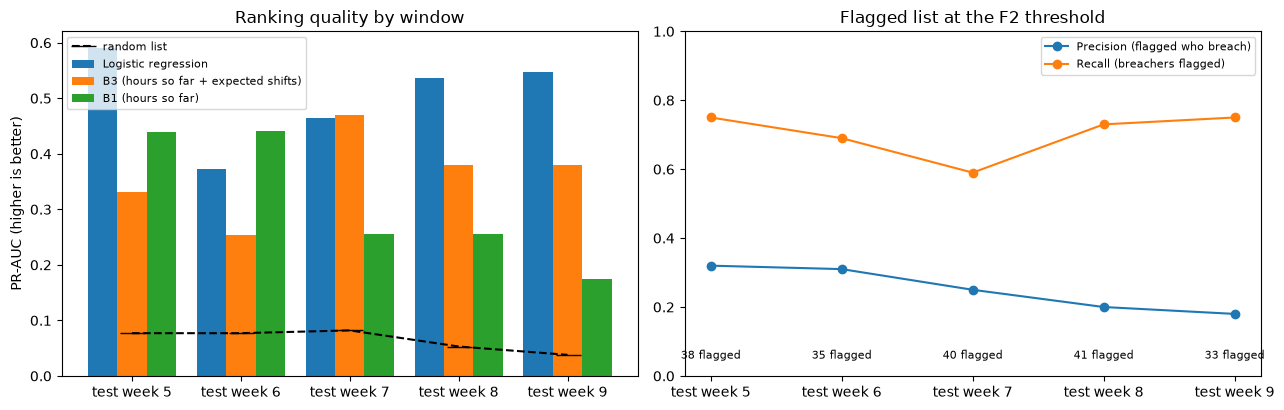

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
w = window_table.iloc[:-1]
x = np.arange(len(w)); labels = [f"test week {i + 5}" for i in range(len(w))]

ax = axes[0]
ax.bar(x - 0.27, w["PR-AUC LR"], 0.27, label="Logistic regression")
ax.bar(x, w["PR-AUC B3"], 0.27, label="B3 (hours so far + expected shifts)")
ax.bar(x + 0.27, w["PR-AUC B1"], 0.27, label="B1 (hours so far)")
ax.plot(x, w["random list"], "k--", marker="_", markersize=18, label="random list")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel("PR-AUC (higher is better)")
ax.set_title("Ranking quality by window"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x, w["precision"], marker="o", label="Precision (flagged who breach)")
ax.plot(x, w["recall"], marker="o", label="Recall (breachers flagged)")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1)
for i, r in enumerate(w.itertuples()):
    ax.annotate(f"{r.flagged} flagged", (i, 0.05), ha="center", fontsize=8)
ax.set_title("Flagged list at the F2 threshold"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading the windows**
- **Against the baselines:** Logistic regression has the best ranking quality (PR-AUC) in 3 of the 5 windows (1, 4 and 5). It beats B3 in 4 of 5. It loses in window 2 (0.37, behind B1 at 0.44) and is essentially level in window 3 (0.47 for logistic regression against 0.47 for B3 and 0.50 for B4). So the model's advantage is not uniform, and the pooled 0.43 against 0.33 hides that.
- **Window 1 is the least reliable:** It trains on only 36 breaches. Its PR-AUC of 0.59 is the highest, but it is a single week with 16 breachers, so we should not read it as a trend.
- **More training weeks did not clearly help:** PR-AUC goes 0.59, 0.37, 0.47, 0.54, 0.55. Window 2 is the dip and the last three are steady, so it is roughly flat once there are a few weeks of history.
- **Flagged list:** The model flags 33 to 41 people a week and recall stays at 0.59 to 0.75 in every window. Precision falls from 0.32 to 0.18 because later test weeks have fewer breachers (8 to 11 in the last two against 16 to 17 in the first three), not because the model got worse. Compare PR-AUC against the random list column instead: it is 5 to 14 times the random value in every window.
- **Noise:** Each test week has only 8 to 17 breachers, so one or two people moving changes a window's numbers noticeably. Treat differences between windows as partly noise.

## 4. Is `risk_score` an honest probability?
Brier score and a calibration table on the out-of-fold predictions.

In [18]:
o = oof["LR"]
print("Brier score LR:", round(brier_score_loss(o.breach, o.score), 4),
      "| base-rate-only Brier:", round(brier_score_loss(o.breach, np.full(len(o), o.breach.mean())), 4))
bins = pd.cut(o.score, [0, .02, .05, .1, .2, .4, 1.0], include_lowest=True)
o.groupby(bins, observed=True).agg(people=("breach", "size"), mean_predicted=("score", "mean"), actual_rate=("breach", "mean")).round(3)

Brier score LR: 0.0476 | base-rate-only Brier: 0.0611


,people,mean_predicted,actual_rate
score,,,
"(-0.001, 0.02]",305,0.010,0.003
"(0.02, 0.05]",365,0.031,0.025
"(0.05, 0.1]",197,0.072,0.076
"(0.1, 0.2]",86,0.138,0.105
"(0.2, 0.4]",45,0.274,0.244
"(0.4, 1.0]",42,0.609,0.548


## 5. Which features matter
Ablation by feature group on the rolling folds, permutation importance on held-out weeks only, and standardised coefficients with bootstrap intervals.

In [19]:
groups = {"hours/shifts so far": ["hours_so_far", "shifts_so_far"],
          "prior weekly pattern": ["avg_weekly_hours_prior", "avg_shifts_prior", "share_long_shifts_prior"],
          "prior breaches": ["prior_breaches"],
          "night pattern": ["night_pattern"]}
full = average_precision_score(oof["LR"].breach, oof["LR"].score)
rows = []
for name, cols in groups.items():
    f = [c for c in FEATS if c not in cols]
    o2 = rolling_cv(table, f)
    rows.append({"dropped group": name, "pooled PR-AUC": round(average_precision_score(o2.breach, o2.score), 3),
                 "change vs full": round(average_precision_score(o2.breach, o2.score) - full, 3)})
print("full model pooled PR-AUC:", round(full, 3))
pd.DataFrame(rows)

full model pooled PR-AUC: 0.43


,dropped group,pooled PR-AUC,change vs full
0,hours/shifts so far,0.278,-0.152
1,prior weekly pattern,0.365,-0.065
2,prior breaches,0.383,-0.047
3,night pattern,0.419,-0.011


In [20]:
# permutation importance on held-out test weeks only (never on training data)
rng = np.random.default_rng(1)
imp = {f: [] for f in FEATS}
for k, m, te in fold_models:
    if te.breach.sum() < 1:
        continue
    base = average_precision_score(te.breach, m.predict_proba(te[FEATS])[:, 1])
    for f in FEATS:
        drops = []
        for _ in range(30):
            shuf = te[FEATS].copy(); shuf[f] = rng.permutation(shuf[f].values)
            drops.append(base - average_precision_score(te.breach, m.predict_proba(shuf)[:, 1]))
        imp[f].append(np.mean(drops))
pd.DataFrame({"mean PR-AUC drop": {f: np.mean(v) for f, v in imp.items()}}).sort_values("mean PR-AUC drop", ascending=False).round(3)

,mean PR-AUC drop
hours_so_far,0.241
prior_breaches,0.120
night_pattern,0.032
avg_weekly_hours_prior,0.025
shifts_so_far,0.022
avg_shifts_prior,0.012
share_long_shifts_prior,-0.005


## 6. Final fit on weeks 2 to 9 and predictions for the in-progress week

In [21]:
def pipeline(seg, feats):
    # full run from segments: table -> rolling folds -> threshold -> final fit -> in-progress-week predictions
    tbl = build_table(seg)
    oof_ = rolling_cv(tbl, feats)
    thr = best_threshold(oof_.breach, oof_.score)
    train = tbl[(tbl.week_start > weeks[0]) & (tbl.week_start < current_week)]
    C = choose_C(tbl, len(weeks) - 1, feats)
    model = make_model(C).fit(train[feats], train.breach)
    cur = tbl[tbl.week_start == current_week].copy()
    cur["risk_score"] = model.predict_proba(cur[feats])[:, 1]
    cur["will_breach"] = (cur["risk_score"] >= thr).astype(int)
    return tbl, oof_, thr, C, model, cur

FINAL_FEATS = FEATS if LR_WINS else ["B3"]
table, oof_final, THRESHOLD, C_FINAL, final_model, cur = pipeline(seg_base, FINAL_FEATS)
print("final features:", FINAL_FEATS, "| C =", C_FINAL, "| will_breach threshold (max F2 on out-of-fold weeks):", round(float(THRESHOLD), 3))
print("people flagged this week:", int(cur.will_breach.sum()), "of", len(cur), "| expected breachers about", round(float(labelled.breach.mean() * len(cur)), 1))
names = person_ids.drop_duplicates("person_key").set_index("person_key")["full_name"]
shown = cur.assign(name=cur.person_key.map(names), projected_hours=cur["B3"], merged_duplicate=cur.person_key.isin(dup_keys))
shown.sort_values("risk_score", ascending=False).head(30)[["person_key", "name", "hours_so_far", "shifts_so_far", "projected_hours", "risk_score", "will_breach", "merged_duplicate"]].round(2)

final features: ['hours_so_far', 'shifts_so_far', 'avg_weekly_hours_prior', 'avg_shifts_prior', 'share_long_shifts_prior', 'prior_breaches', 'night_pattern'] | C = 0.3 | will_breach threshold (max F2 on out-of-fold weeks): 0.096
people flagged this week: 46 of 208 | expected breachers about 13.0


,person_key,name,hours_so_far,shifts_so_far,projected_hours,risk_score,will_breach,merged_duplicate
1106,E1126,Lerato Motaung,38.75,4.0,58.93,0.95,1,True
863,E1099,Portia Fourie,51.75,5.0,51.75,0.88,1,False
854,E1097,Busisiwe Jacobs,29.50,3.0,61.17,0.83,1,True
314,E1035,Tshepo Motaung,34.50,3.0,60.35,0.75,1,True
800,E1090,Pieter Van Wyk,28.50,3.0,58.76,0.72,1,True
386,E1044,Mandla Sithole,36.00,3.0,50.18,0.71,1,False
1205,E1138,Riaan Fourie,37.25,3.0,49.94,0.70,1,False
1700,E1193,Lucky Sibiya,28.25,3.0,57.02,0.67,1,True
1151,E1132,Kabelo Fourie,38.50,3.0,51.76,0.57,1,False
1061,E1121,Kagiso Molefe,34.75,3.0,47.54,0.45,1,False


In [22]:
# standardised coefficients with bootstrap intervals (logistic regression only)
if LR_WINS:
    train = table[(table.week_start > weeks[0]) & (table.week_start < current_week)]
    rng = np.random.default_rng(2)
    coefs = []
    for _ in range(300):
        b = train.sample(len(train), replace=True, random_state=int(rng.integers(1e9)))
        if b.breach.sum() < 3: continue
        coefs.append(make_model(C_FINAL).fit(b[FEATS], b.breach)[-1].coef_[0])
    coefs = np.array(coefs)
    display(pd.DataFrame({"coef": final_model[-1].coef_[0], "ci_low": np.percentile(coefs, 2.5, axis=0), "ci_high": np.percentile(coefs, 97.5, axis=0)}, index=FEATS).round(2))

,coef,ci_low,ci_high
hours_so_far,1.13,0.82,1.46
shifts_so_far,-0.12,-0.46,0.23
avg_weekly_hours_prior,0.38,0.10,0.70
avg_shifts_prior,0.31,-0.08,0.63
share_long_shifts_prior,0.13,-0.25,0.38
prior_breaches,0.24,0.08,0.44
night_pattern,0.27,0.05,0.49


### One person's score, step by step
The highest-risk person this week: each feature's contribution to the log-odds, then the probability.

In [23]:
if LR_WINS:
    top = cur.sort_values("risk_score", ascending=False).iloc[0]
    scaler, lr = final_model[0], final_model[-1]
    z = scaler.transform(pd.DataFrame([top[FEATS]]))[0]
    steps = pd.DataFrame({"raw value": top[FEATS].values, "standardised": z, "coefficient": lr.coef_[0], "contribution": z * lr.coef_[0]}, index=FEATS)
    logit = lr.intercept_[0] + steps["contribution"].sum()
    assert abs(1 / (1 + np.exp(-logit)) - top.risk_score) < 1e-9
    print(f"{names[top.person_key]} ({top.person_key}): intercept {lr.intercept_[0]:.2f} + contributions {steps.contribution.sum():.2f} = log-odds {logit:.2f} -> probability {top.risk_score:.2f}")
    display(steps.round(2))

Lerato Motaung (E1126): intercept -3.51 + contributions 6.46 = log-odds 2.95 -> probability 0.95


,raw value,standardised,coefficient,contribution
hours_so_far,38.75,2.43,1.13,2.75
shifts_so_far,4.0,2.45,-0.12,-0.29
avg_weekly_hours_prior,58.416667,3.05,0.38,1.15
avg_shifts_prior,6.111111,2.14,0.31,0.66
share_long_shifts_prior,0.145455,-0.48,0.13,-0.06
prior_breaches,7.0,9.72,0.24,2.36
night_pattern,0,-0.41,0.27,-0.11


## 7. Does week 10 look like the training weeks?
Hours so far are only slightly higher than usual (about 0.2 standard deviations; one Sunday shift is attributed to Monday and Monday is a public holiday), and `prior_breaches` is higher because there is more history. Neither is large, but week 10 is the one place where the model has never seen the exact conditions.

In [24]:
train_rows = table[(table.week_start > weeks[0]) & (table.week_start < current_week)]
dist = pd.DataFrame({"training mean": train_rows[FEATS].mean(), "training max": train_rows[FEATS].max(),
                     "week 10 mean": cur[FEATS].mean(), "week 10 max": cur[FEATS].max()})
dist["gap in training std"] = (dist["week 10 mean"] - dist["training mean"]) / train_rows[FEATS].std()
dist.round(2)

,training mean,training max,week 10 mean,week 10 max,gap in training std
hours_so_far,19.25,48.50,20.89,51.75,0.20
shifts_so_far,1.96,5.00,2.10,5.00,0.17
avg_weekly_hours_prior,43.08,66.75,43.00,59.25,-0.02
avg_shifts_prior,4.40,8.00,4.40,6.44,-0.00
share_long_shifts_prior,0.31,1.00,0.30,1.00,-0.01
prior_breaches,0.27,6.00,0.55,7.00,0.40
night_pattern,0.14,1.00,0.14,1.00,0.00


## 8. Secondary check and sensitivity runs
Group k-fold by person (does it generalise to unseen employees?), then two reruns of the whole pipeline: missing clock-outs imputed with the person's median shift length, and weeks counted by clock-in date instead of the greater-portion rule.

In [25]:
lab = table[(table.week_start > weeks[0]) & (table.week_start < current_week)]
oof_g = pd.Series(index=lab.index, dtype=float)
for tr_i, te_i in GroupKFold(5).split(lab, lab.breach, lab.person_key):
    m = make_model(C_FINAL).fit(lab.iloc[tr_i][FEATS], lab.iloc[tr_i].breach)
    oof_g.iloc[te_i] = m.predict_proba(lab.iloc[te_i][FEATS])[:, 1]
print("group k-fold by person, PR-AUC:", round(average_precision_score(lab.breach, oof_g), 3),
      "| base rate", round(lab.breach.mean(), 3)) if LR_WINS else print("group k-fold applies to the logistic regression only")

group k-fold by person, PR-AUC: 0.413 | base rate 0.062


In [26]:
def compare(label, alt_cur):
    a = cur.set_index("person_key"); b = alt_cur.set_index("person_key").reindex(a.index)
    both = int(((a.will_breach == 1) & (b.will_breach == 1)).sum())
    print(f"{label}: flagged {int(b.will_breach.sum())} (base {int(a.will_breach.sum())}) | in both {both} | "
          f"predictions that differ {int((a.will_breach != b.will_breach).sum())} | rank correlation {a.risk_score.corr(b.risk_score, method='spearman'):.2f}")

# (a) missing clock-outs imputed with the person's median shift length
valid = shifts[~shifts.excluded]
med = valid.groupby("employee_id")["duration_hours"].median()
miss = shifts[shifts.clock_out_time.isna() & shifts.clock_in_time.notna() & ~shifts.invalid_date].copy()
miss["hours"] = miss["employee_id"].map(med).fillna(valid["duration_hours"].median())
miss = add_person_key(miss, people)
miss["week_start"] = miss["shift_date"] - pd.to_timedelta(miss["shift_date"].dt.weekday, unit="D")
seg_imputed = pd.concat([seg_base, miss[["shift_id", "person_key", "shift_date", "week_start", "hours"]]], ignore_index=True)
_, _, _, _, _, cur_imputed = pipeline(seg_imputed, FINAL_FEATS)
compare("imputed clock-outs", cur_imputed)

# (b) weeks counted by the clock-in date instead of the greater-portion rule
v = add_person_key(valid, people)
v = v.assign(hours=v["duration_hours"], week_start=v["shift_date"] - pd.to_timedelta(v["shift_date"].dt.weekday, unit="D"))
seg_clockin = v[["shift_id", "person_key", "shift_date", "week_start", "hours"]]
_, _, _, _, _, cur_clockin = pipeline(seg_clockin, FINAL_FEATS)
compare("clock-in-date weeks", cur_clockin)

imputed clock-outs: flagged 60 (base 46) | in both 46 | predictions that differ 14 | rank correlation 0.97


clock-in-date weeks: flagged 36 (base 46) | in both 35 | predictions that differ 12 | rank correlation 0.93


## 9. Output: `predictions.csv`
One row for each of the 213 employee IDs. Both IDs of a merged person get the same prediction. Provisional until reviewed.

In [27]:
by_person = cur.set_index("person_key")[["will_breach", "risk_score"]]
predictions = (person_ids[["employee_id", "person_key"]]
               .join(by_person, on="person_key")[["employee_id", "will_breach", "risk_score"]]
               .sort_values("employee_id").reset_index(drop=True))
predictions["will_breach"] = predictions["will_breach"].astype(int)
predictions["risk_score"] = predictions["risk_score"].round(4)

assert list(predictions.columns) == ["employee_id", "will_breach", "risk_score"]
assert len(predictions) == len(employees) == 213 and predictions.employee_id.is_unique
assert set(predictions.employee_id) == set(employees.employee_id)
assert predictions.will_breach.isin([0, 1]).all() and predictions.risk_score.between(0, 1).all()
for _, g in person_ids.groupby("person_key"):          # both IDs of a merged person match
    assert predictions[predictions.employee_id.isin(g.employee_id)][["will_breach", "risk_score"]].nunique().max() == 1

predictions.to_csv("predictions.csv", index=False)
print("wrote predictions.csv:", len(predictions), "rows,", int(predictions.will_breach.sum()), "flagged")
predictions.head()

wrote predictions.csv: 213 rows, 51 flagged


,employee_id,will_breach,risk_score
0,E1001,0,0.0475
1,E1002,0,0.0307
2,E1003,0,0.0381
3,E1004,1,0.2099
4,E1005,1,0.1473


## Summary of results (read before trusting the output)
**Does the model beat the baselines?** Yes. Pooled out-of-fold PR-AUC is 0.43 for logistic regression against 0.33 for the best simple baseline (B3, hours so far plus expected remaining shifts), 0.31 for hours so far and 0.30 for average prior hours. It wins 4 of the 5 folds. Without the 5 merged people it is 0.36 against 0.17 for B3, so the gain does not depend on them. A random list would score about 0.06, the base rate. Group k-fold by person gives 0.41, so it also works for people it has not seen.

**What drives it.** Hours worked so far this week is by far the biggest factor (dropping it costs 0.15 PR-AUC), then breach history, then the prior weekly pattern. Because Monday-to-Wednesday and Thursday-to-Sunday hours are negatively correlated, a naive projection of hours so far is poor. The model learns it from the person's usual shifts per week.

**Is the score honest?** Brier score 0.048 against 0.061 for always predicting the base rate, and the calibration table is close to the diagonal (people scored 0.4 to 1.0 breached 55% of the time).

**This week.** 46 people (51 employee IDs) are flagged, against about 13 expected breachers. At the chosen threshold the out-of-fold precision is about 0.25 and recall about 0.69, so roughly three in four flagged people will not breach, and about a third of real breachers are still missed. The list is longer than the 25 to 35 names we aimed for because F2 favours recall; the ranked score lets the manager read down it as far as they have time.

**Where not to trust it.**
- Few positives: only 8 to 17 breachers in each test week, so fold-to-fold swings are noise, and the first fold trains on only 36 positives.
- The 5 merged duplicate people breach in about 7 of 8 weeks. `prior_breaches` is 9.7 standard deviations out for one of them, and they fill the top of the list. They are real repeat breachers under our rules, but the model's confidence there is largely their history.
- The week attribution rule matters: counting weeks by clock-in date flags 36 people instead of 46 (12 predictions differ), and imputing missing clock-outs flags 60 (14 differ).
- The greater-portion rule is in effect for the labels, features and predictions (our decision). If the checker's ground truth counts weeks differently, who is flagged will change; the clock-in-date rerun above shows by how much.